# Tweet classification — weighted keyword scoring

Classifies a sample of tweets from `src.config.TARGETS` against the 3-category
taxonomy in `src/ml/tm_reference.py` (`TOPIC_KEYWORDS`), using language ID +
real stemming (nltk `ISRIStemmer`/`SnowballStemmer`) + IDF-weighted keyword
matching. Zero-shot/ensemble stages are deferred — this is the interpretable
baseline.

In [ ]:
import math
import os
import re
import sqlite3
import sys
from collections import Counter

# Jupyter's default kernel cwd is the notebook's own directory (src/ml/), not
# the project root, so `import src...` needs the root added explicitly.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

import matplotlib.pyplot as plt
import pandas as pd
from langdetect import DetectorFactory, LangDetectException, detect
from nltk.stem import ISRIStemmer, SnowballStemmer

from src.config import TARGETS
from src.ml.tm_reference import TOPIC_KEYWORDS

DetectorFactory.seed = 0

CATEGORIES = list(TOPIC_KEYWORDS.keys())
STEMMERS = {"ar": ISRIStemmer(), "fr": SnowballStemmer("french"), "en": SnowballStemmer("english")}

# Guard against stemmer over-collapsing: e.g. "Fasting" -> "fast" collides with the
# unrelated common word "fast" (speed). A real inflection always has the stemmer
# strip at least one character (e.g. "fasting" -> "fast", "organisé" -> "organis",
# "استقرار" -> "قرر"). So a token that already IS the stem, unchanged, only counts
# as a hit if some source keyword is itself that short — otherwise it's coincidence,
# not an inflection of the longer keyword(s) that produced this stem. This applies
# uniformly across languages (no special-casing needed for Arabic's root stemmer).
STEM_NEEDS_INFLECTION: dict[str, set[str]] = {lang: set() for lang in STEMMERS}

URL_RE = re.compile(r"https?://\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
AR_DIACRITICS_RE = re.compile(r"[ؗ-ًؚ-ْ]")
AR_ALEF_RE = re.compile(r"[إأآ]")


def clean_text(text: str) -> str:
    text = URL_RE.sub("", text)
    text = MENTION_RE.sub("", text)
    text = HASHTAG_RE.sub(r"\1", text)
    return re.sub(r"\s+", " ", text).strip()


def detect_lang(cleaned: str) -> str:
    if len(cleaned) < 3:
        return "other"
    try:
        code = detect(cleaned)
    except LangDetectException:
        return "other"
    return code if code in STEMMERS else "other"


def stem_tokens(cleaned: str, lang: str) -> list[str]:
    text = AR_ALEF_RE.sub("ا", AR_DIACRITICS_RE.sub("", cleaned)) if lang == "ar" else cleaned.lower()
    raw_tokens = re.findall(r"\w+", text, re.UNICODE)
    stem = STEMMERS[lang].stem
    stems = []
    for t in raw_tokens:
        s = stem(t)
        if len(t) == len(s) and s in STEM_NEEDS_INFLECTION[lang]:
            continue
        stems.append(s)
    return stems

## Stem the keyword dictionary

Stem `TOPIC_KEYWORDS` once so matching against tweets is stem-to-stem instead
of substring/regex — catches inflected forms like "بالدبلوماسية" or
"diplomatique".

In [ ]:
STEMMED_KEYWORDS = {
    cat: {lang: {stem_tokens(w, lang)[0] for w in words} for lang, words in langs.items()}
    for cat, langs in TOPIC_KEYWORDS.items()
}
_stem_keyword_lens: dict[str, dict[str, int]] = {lang: {} for lang in STEMMERS}
for _langs in TOPIC_KEYWORDS.values():
    for _lang, _words in _langs.items():
        for _w in _words:
            _s = stem_tokens(_w, _lang)[0]
            _lens = _stem_keyword_lens[_lang]
            _lens[_s] = min(_lens.get(_s, len(_w)), len(_w))
for _lang, _lens in _stem_keyword_lens.items():
    for _s, _shortest_keyword_len in _lens.items():
        if _shortest_keyword_len > len(_s):
            STEM_NEEDS_INFLECTION[_lang].add(_s)

ALL_KEYWORD_STEMS = {
    lang: set().union(*(STEMMED_KEYWORDS[cat][lang] for cat in CATEGORIES)) for lang in STEMMERS
}

STEMMED_KEYWORDS["diplomatic-relational"]["ar"]

## Load sample: 10 random tweets per target

In [3]:
conn = sqlite3.connect(os.path.join(PROJECT_ROOT, "data.db"))
rows = []
for target in TARGETS:
    for tweet_id, text in conn.execute(
        "SELECT t.id, t.text FROM tweets t JOIN users u ON t.user_id = u.id "
        "WHERE u.username = ? COLLATE NOCASE ORDER BY RANDOM() LIMIT 50",
        (target,),
    ).fetchall():
        rows.append({"target": target, "tweet_id": tweet_id, "text": text})
conn.close()

df = pd.DataFrame(rows)
print(f"loaded {len(df)} tweets across {df['target'].nunique()} targets")
df.head()

loaded 2781 tweets across 57 targets


,target,tweet_id,text
0,habousmaroc,581496889473966081,"SM le Roi, Amir Al Mouminine, inaugure à Rabat..."
1,habousmaroc,889810269794443264,مؤسسة دار الحديث الحسنية: هشام الغزالي رئيسا ل...
2,habousmaroc,1941078363151737310,موسم حج 2026/1447: تأدية مصاريف الحج من 21 يول...
3,habousmaroc,1882067146131571120,الخطبة المنبرية: معجزة الإسراء والمعراج\n\nنست...
4,habousmaroc,1863921039366836294,ذ. سعيد بيهي : عوائق التبليغ رصد وتجاوز\n\nذ. ...


## Preprocess: clean, detect language, stem

In [4]:
df["cleaned"] = df["text"].map(clean_text)
df["lang"] = df["cleaned"].map(detect_lang)
df = df[df["lang"].isin(STEMMERS)].reset_index(drop=True)  # keep ar/fr/en only
df["tokens"] = df.apply(lambda r: stem_tokens(r["cleaned"], r["lang"]), axis=1)

df["lang"].value_counts()

lang
en    1237
ar     967
fr      58
Name: count, dtype: int64

## Weighted keyword scoring

IDF weight per stemmed keyword = `log((1+N_lang)/(1+df)) + 1`, computed only
over the language's own sample so common words score low and rare/distinctive
ones score high. Category score = sum of weighted hits, normalized by tweet
length. Label = argmax category if its score clears 0, else `unclassified`.

In [5]:
# document frequency per language, only over stems that appear in the keyword lists
df_counts = {lang: Counter() for lang in STEMMERS}
n_lang = df["lang"].value_counts().to_dict()

for lang, group in df.groupby("lang"):
    if lang not in STEMMERS:
        continue
    for tokens in group["tokens"]:
        for t in set(tokens) & ALL_KEYWORD_STEMS[lang]:
            df_counts[lang][t] += 1

idf = {
    lang: {t: math.log((1 + n_lang.get(lang, 0)) / (1 + c)) + 1 for t, c in df_counts[lang].items()}
    for lang in STEMMERS
}


def score_row(lang: str, tokens: list[str]) -> dict[str, float]:
    if lang not in STEMMERS or not tokens:
        return {c: 0.0 for c in CATEGORIES}
    counts = Counter(tokens)
    denom = math.log(2 + len(tokens))
    return {
        cat: sum(counts[t] * idf[lang].get(t, 0.0) for t in STEMMED_KEYWORDS[cat][lang]) / denom
        for cat in CATEGORIES
    }


scores = df.apply(lambda r: score_row(r["lang"], r["tokens"]), axis=1)
for cat in CATEGORIES:
    df[cat] = scores.map(lambda s: s[cat])

df["category"] = df[CATEGORIES].idxmax(axis=1)
df.loc[df[CATEGORIES].max(axis=1) <= 0, "category"] = "unclassified"

df["category"].value_counts()

category
unclassified             1042
diplomatic-relational     599
digital-influential       315
religious-referential     306
Name: count, dtype: int64

## Per-target category distribution

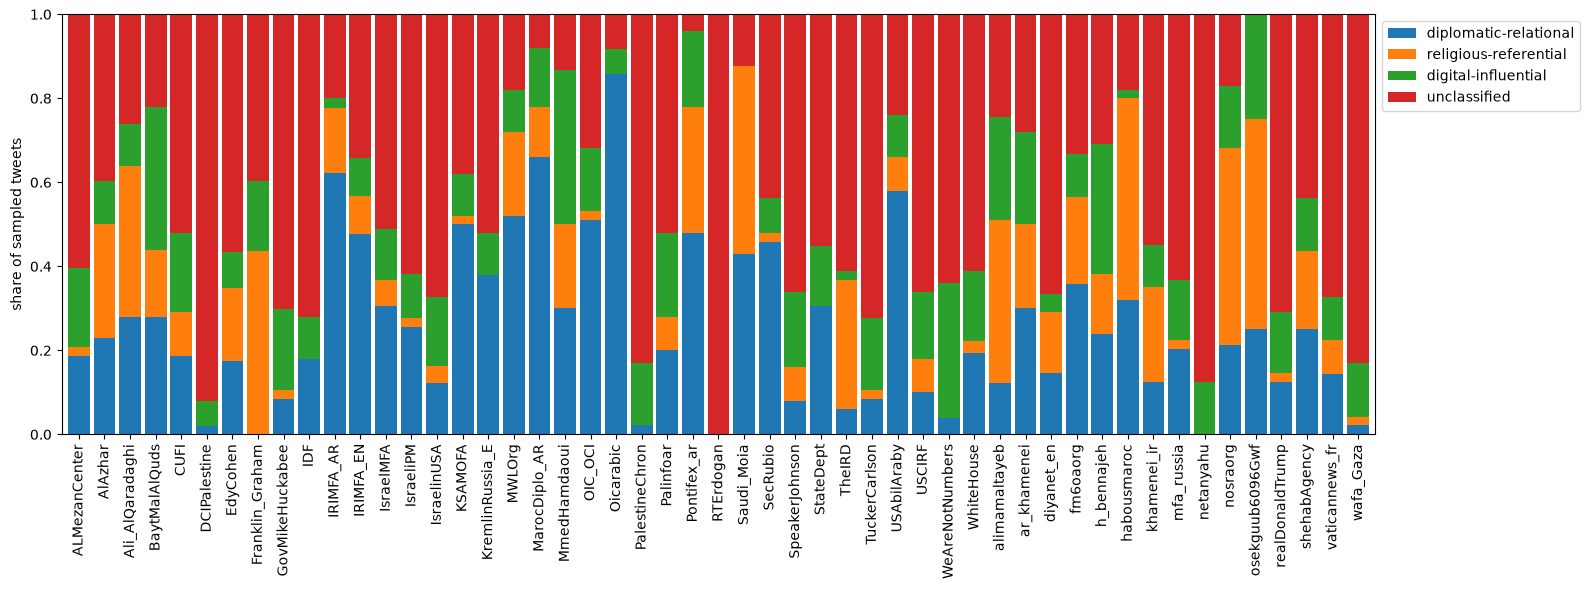

In [6]:
dist = pd.crosstab(df["target"], df["category"], normalize="index")
dist = dist[[c for c in [*CATEGORIES, "unclassified"] if c in dist.columns]]

ax = dist.plot(kind="bar", stacked=True, figsize=(16, 6), width=0.85)
ax.set_ylabel("share of sampled tweets")
ax.set_xlabel("")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

## Unclassified rate per language

Sanity check for coverage gaps — the religious-referential keyword list is
shorter than diplomatic-relational's, so it likely under-scores.

In [7]:
(df["category"] == "unclassified").groupby(df["lang"]).mean().sort_values(ascending=False)

lang
fr    0.672414
en    0.624899
ar    0.237849
Name: category, dtype: float64

## Spot-check examples per category

In [8]:
for cat in [*CATEGORIES, "unclassified"]:
    print(f"\n--- {cat} ---")
    for _, r in df[df["category"] == cat].head(3).iterrows():
        print(f"  [{r['target']} / {r['lang']}] {r['text'][:100]!r}")


--- diplomatic-relational ---
  [habousmaroc / ar] 'ذ. سعيد بيهي : عوائق التبليغ رصد وتجاوز\n\nذ. سعيد بيهي : عوائق التبليغ رصد وتجاوز\nملخص مداخلة الأستاذ'
  [habousmaroc / ar] 'قرار 2136.24 بتتميم كيفيات منح الترخيص بفتح مؤسسة للتعليم العتيق أو توسيعها أو إدخال تغييرات عليها..'
  [habousmaroc / ar] 'مشاركة وزارة الأوقاف والشؤون الإسلامية في المعرض الدولي للكتاب الدورة 28  بمجموعة من الأنشطة الثقافي'

--- religious-referential ---
  [habousmaroc / ar] 'موسم حج 2026/1447: تأدية مصاريف الحج من 21 يوليو إلى 08 أغسطس 2025 بمكاتب بريد بنك بمختلف عمالات وأق'
  [habousmaroc / ar] 'الخطبة المنبرية: معجزة الإسراء والمعراج\n\nنستقبل هذه الأيام نفحة من نفحات هذا الشهر المبارك؛ ومنحة من'
  [habousmaroc / ar] 'مواقيت الصلاة لشهر رجب 1446هـ\n\nللاطلاع على حصة مواقيت الصلاة الخاصة بشهر رجب 1446هـ الموافق لشهر ينا'

--- digital-influential ---
  [habousmaroc / ar] 'مؤسسة دار الحديث الحسنية: هشام الغزالي رئيسا لمصلحة الموارد البشرية والمالية https://t.co/QXrBAWhHq2'
  [MarocDiplo_AR / ar] '🇿🇲-🇲🇦 | اس